In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.container import BarContainer
df = pd.read_csv(r'C:\Users\RISHABH SINGH\Desktop\PYTHON\Dataset .csv')

In [3]:
df

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [4]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [9]:
df['Cuisines']=df['Cuisines'].fillna("Not Appeared")

In [10]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Level 1



Task:Top Cuisines 

Sub-Task-1 : Determine the top three most
common cuisines in the dataset.

In [11]:
Top_3_Cuisines=df['Cuisines'].value_counts().head(3)
print(Top_3_Cuisines) 

Cuisines
North Indian             936
North Indian, Chinese    511
Fast Food                354
Name: count, dtype: int64


C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_25920\1641233778.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  x=sns.barplot(x=Top_3_Cuisines.index,y=Top_3_Cuisines.values,palette='cubehelix')


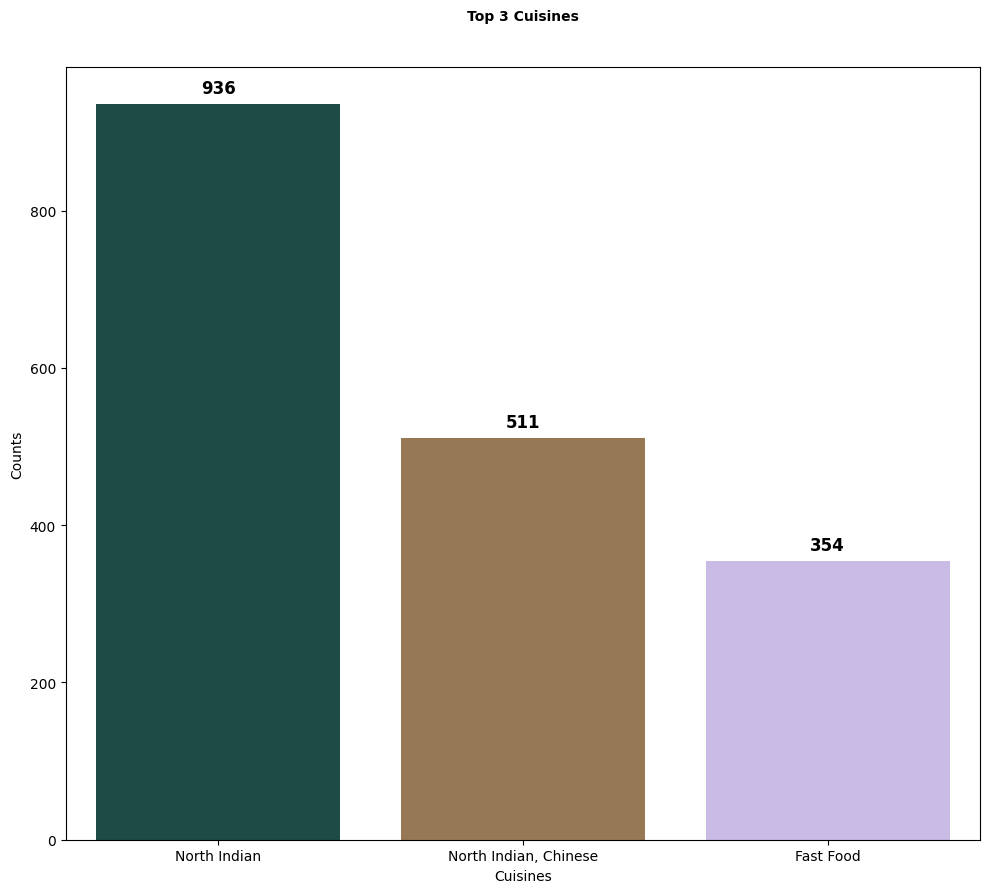

In [12]:
plt.figure(figsize=(10,9))
x=sns.barplot(x=Top_3_Cuisines.index,y=Top_3_Cuisines.values,palette='cubehelix')
for container in x.containers:
    x.bar_label(container,padding=5,fontsize=12,fontweight='bold')
plt.xlabel('Cuisines')
plt.ylabel('Counts')
plt.title('Top 3 Cuisines',y=1.05,fontsize=10,fontweight='bold')
plt.tight_layout()
plt.savefig('Top 3 Cuisines',dpi=300,bbox_inches='tight')
plt.show()

Sub-Task-2 : Calculate the percentage of restaurants that serve each of the top cuisines.

In [13]:
cuisines_split = df['Cuisines'].str.split(',').explode()
cuisines_counts = (cuisines_split.value_counts()/len(df)).to_frame().style.format('{:.2%}').background_gradient(cmap='gnuplot')
print('Percentages of restaurants serving top cuisines')
cuisines_counts



Percentages of restaurants serving top cuisines


,count
Cuisines,
North Indian,31.33%
Chinese,19.68%
Fast Food,13.76%
North Indian,10.14%
Chinese,8.95%
Mughlai,8.17%
Fast Food,7.04%
Bakery,6.50%
Cafe,6.46%


C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_25920\1991429929.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  x=sns.barplot(x=cuisines_pct.head(10).index, y=cuisines_pct.head(10).values,palette='magma')


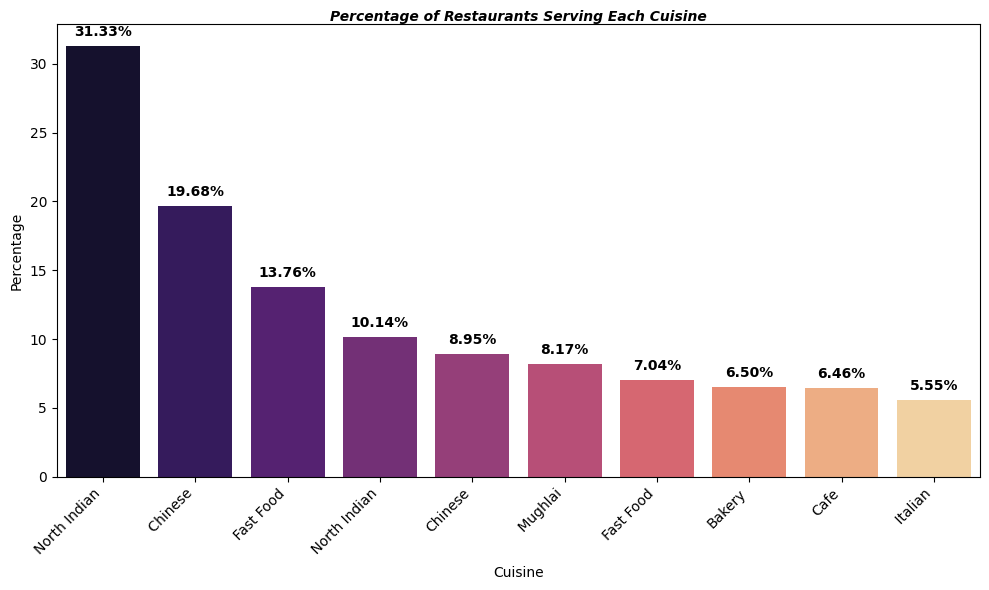

In [ ]:
plt.figure(figsize=(10,6))
cuisines_pct =(cuisines_split.value_counts() / len(df))*100
x=sns.barplot(x=cuisines_pct.head(10).index, y=cuisines_pct.head(10).values,palette='magma')
for container in x.containers:
    if isinstance(container, BarContainer):
        x.bar_label(container, padding=5, fontsize=10, fontweight='bold', fmt='%.2f%%')
plt.xlabel('Cuisine')
plt.ylabel('Percentage')
plt.title('Percentage of Restaurants Serving Each Cuisine', fontsize=10, fontweight='bold', fontstyle='italic', pad=1.08)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Percentage of Restaurants Serving Each Cuisine',dpi=300,bbox_inches='tight')
plt.show()

Task-2:City Analysis

Sub-Task-1:Identify the city with the highest number of restaurants in the dataset

In [8]:
Highest_rst=df['City'].value_counts().idxmax()

print(f'The city which have highest no. of restaurants is : {Highest_rst}')

The city which have highest no. of restaurants is : New Delhi


In [12]:
#Top ten cities with highest no. of restaurants 
Top_10_Cities=df['City'].value_counts().nlargest(10).index
df_top_10_cities=df[df['City'].isin(Top_10_Cities)]
print(f'Top 10 cities with highest no. of restaurants are : \n{Top_10_Cities}')


Top 10 cities with highest no. of restaurants are : 
Index(['New Delhi', 'Gurgaon', 'Noida', 'Faridabad', 'Ghaziabad',
       'Bhubaneshwar', 'Lucknow', 'Ahmedabad', 'Amritsar', 'Guwahati'],
      dtype='object', name='City')


C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_34384\80748257.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  x=sns.countplot(y='City', data=df_top_10_cities, order=Top_10_Cities, palette='viridis')


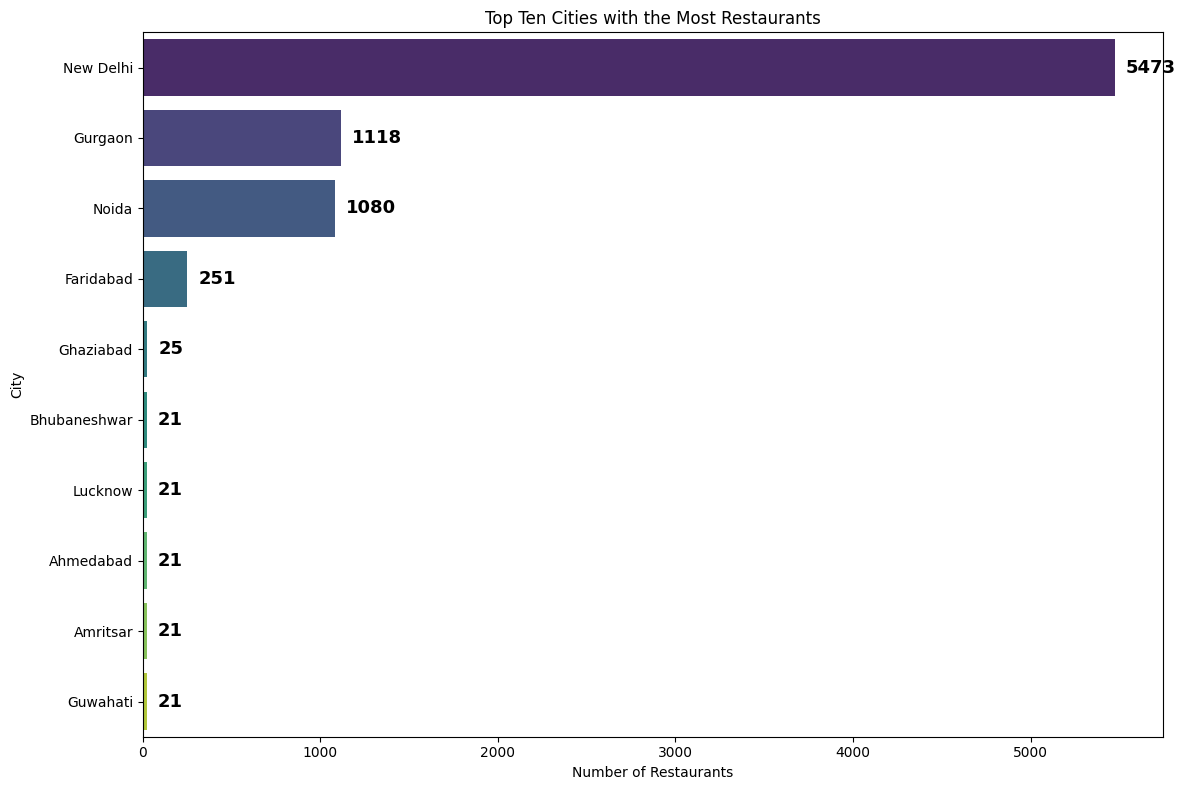

In [15]:
plt.figure(figsize=(12, 8))
x=sns.countplot(y='City', data=df_top_10_cities, order=Top_10_Cities, palette='viridis')
for container in x.containers:
    if isinstance(container,BarContainer):
        x.bar_label(container,padding=8,fontsize=13,fontweight='bold')
plt.title('Top Ten Cities with the Most Restaurants')
plt.xlabel('Number of Restaurants')
plt.ylabel('City')
plt.tight_layout()
plt.savefig('Top 10 cities with Most Restaurants.png',dpi=300,bbox_inches='tight')
plt.show()

Sub-Task-2:Calculate the average rating for restaurants in each city

In [32]:
Cities_Avg_Rating=city.sort_values(ascending=False)
print(f'Average ratings of cities are : {Cities_Avg_Rating}')

Average ratings of cities are : City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
                      ...   
New Delhi           2.438845
Montville           2.400000
Mc Millan           2.400000
Noida               2.036204
Faridabad           1.866932
Name: Aggregate rating, Length: 141, dtype: float64


C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_34384\2783896445.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  x = sns.barplot(y=Cities_Avg_Rating.sort_values(ascending=False).head(10).index, x=Cities_Avg_Rating.sort_values(ascending=False).head(10).values, palette='rainbow', orient='h')


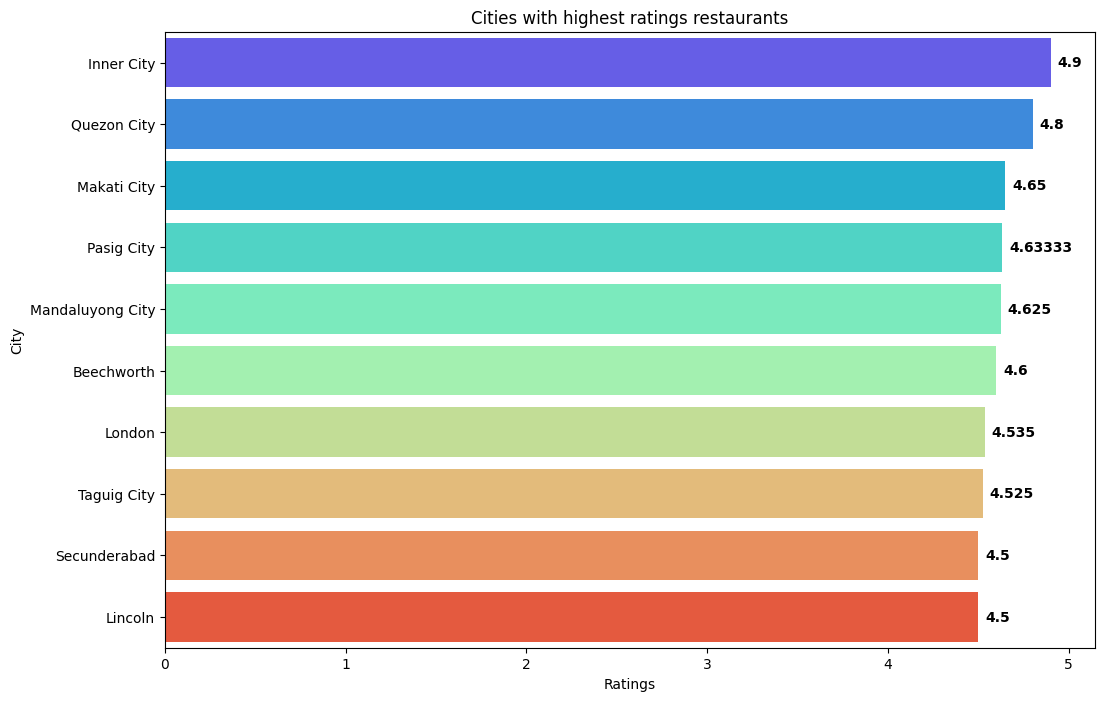

In [39]:
plt.figure(figsize=(12,8))
x = sns.barplot(y=Cities_Avg_Rating.sort_values(ascending=False).head(10).index, x=Cities_Avg_Rating.sort_values(ascending=False).head(10).values, palette='rainbow', orient='h')
for container in x.containers:
    x.bar_label(container, padding=5, fontsize=10, fontweight='bold')
plt.title('Cities with highest ratings restaurants')
plt.xlabel('Ratings')
plt.ylabel('City')
plt.savefig('Top 10 cities with Highest Rating Restaurants.png',dpi=300,bbox_inches='tight')

Sub-Task-3:Determine the city with the highest average rating.

In [31]:
city=df.groupby('City')['Aggregate rating'].mean()
Highest_Avg_Rating_City = city.idxmax()
print(f'City with the highest rating restaurant : {Highest_Avg_Rating_City} ')

City with the highest rating restaurant : Inner City 


Task-3:Price Range Distribution

Sub-Task-1:Create a histogram or bar chart to visualize the distribution of price ranges among the restaurants.

In [10]:
Price_tags={1:'Inexpensive/Budget',
            2:'Moderate/Mid-range',3:'Expensive/Upscale',4:'Very Expensive/Luxury'}
df['Price_Tags']=df['Price range'].map(Price_tags)

C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_6000\2810327314.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x='Price_Tags', data=df,kde=True,kde_kws={'bw_adjust': 0.5},palette='gnuplot')


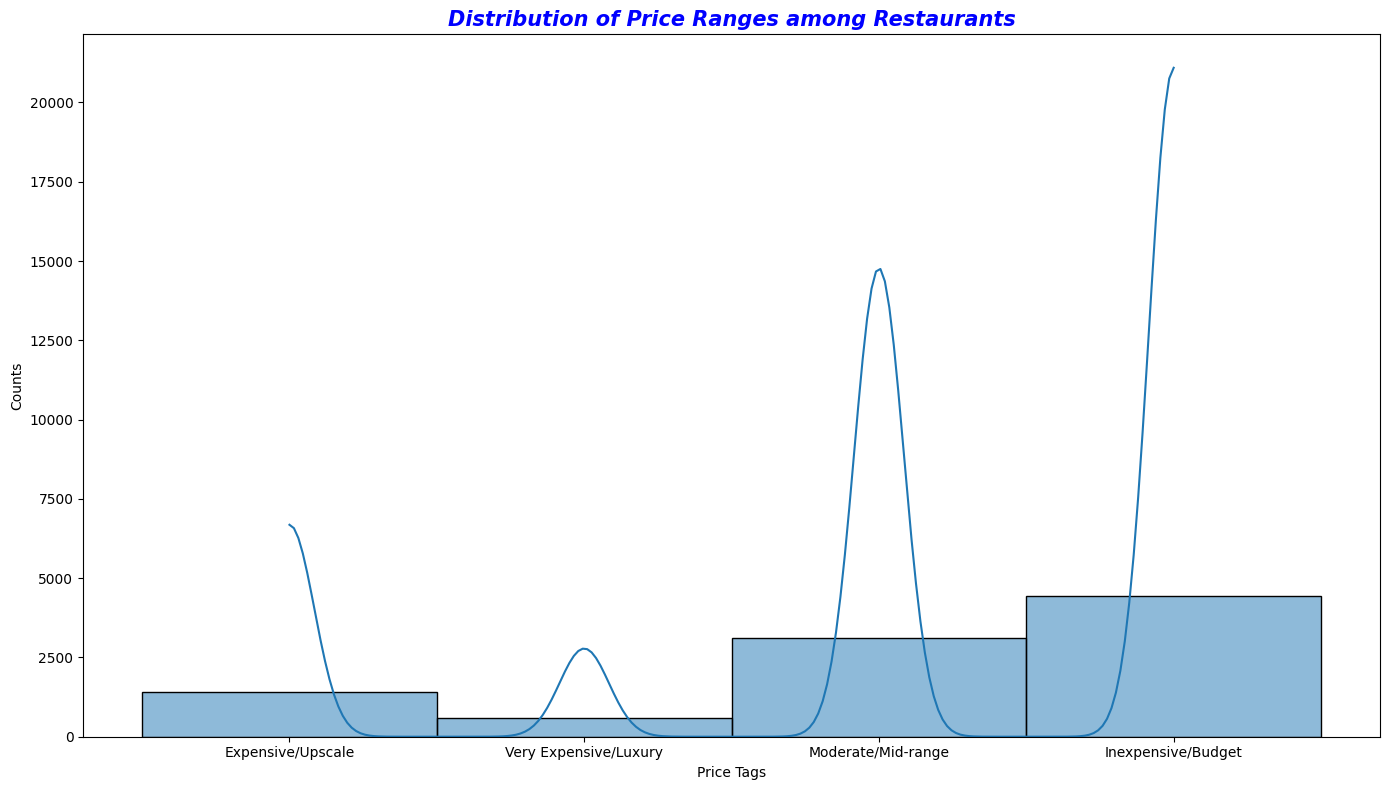

In [22]:
plt.figure(figsize=(14,8))
sns.histplot(x='Price_Tags', data=df,kde=True,kde_kws={'bw_adjust': 0.5},palette='gnuplot')
plt.title('Distribution of Price Ranges among Restaurants', fontsize=15, fontweight='bold', fontstyle='italic', color='blue')
plt.xlabel('Price Tags')
plt.ylabel('Counts')
plt.tight_layout()
plt.savefig('Ditribution of Price Ranges among Restaurants.png',dpi=300,bbox_inches='tight')
plt.show()

Sub-Task-2 : Calculate the percentage of restaurants in each price range category.


In [26]:
Percentage_Rest_Price_Range=df['Price range'].value_counts()/len(df)

print(f'The percentage of restaurants in each price range category:') 

res=Percentage_Rest_Price_Range.to_frame().style.format('{:.2%}').background_gradient(cmap='magma')
res
      


The percentage of restaurants in each price range category:


,count
Price range,
1,46.53%
2,32.59%
3,14.74%
4,6.14%


Task-4: Online Delivery

Sub-Task-1 : Determine the percentage of restaurants that offer online delivery.

In [42]:
Rest_Online_Delivery = (df['Has Online delivery'].value_counts(normalize=True).get('Yes', 0) * 100)
Rest_Online_Delivery = round(Rest_Online_Delivery, 2)

print(f"The percentage of restaurants who offers online delivery:\n{Rest_Online_Delivery}%")


The percentage of restaurants who offers online delivery:
25.66%


Sub-Task-2 : Compare the average ratings of restaurants with and without online delivery

In [44]:
Avg_rating_rest=df.groupby('Has Online delivery')['Aggregate rating'].mean()
print(f"The average ratings of restaurants with and without online delivery:{round(Avg_rating_rest,2)}")

The average ratings of restaurants with and without online delivery:Has Online delivery
No     2.47
Yes    3.25
Name: Aggregate rating, dtype: float64
